# WFS controls for operation at ALS beamline 5.3.1
awojdyla@lbl.gov,  khchan@lbl.gov,  francisho@lbl.gov, walangrizolli@lbl.gov,

Analyzing data collected on March 27, 2026 (collected on central tiled server, without binning.)

We want to show that we can get wavefront data, remove polymials, plot the caustics, and maybe use the Frankot-Chelappa algorithm
https://mywavepy.readthedocs.io/en/latest/source/api/wavepy.surface_from_grad.html
https://github.com/APS-XSD-OPT-Group/wavepy/blob/master/wavepy/surface_from_grad.py

APS WAF analysis is available here:
https://github.com/APS-XSD-OPT-Group/WFSuite



## Connect to the Tiled server

In [1]:
from tiled.client import from_uri
#client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw", api_key=central_tiled_api_key)
client = from_uri("https://tiled.computing.als.lbl.gov/api/v1/metadata/beamlines/bl531/raw")


You have 15 minutes to visit this URL

https://comp-auth.als.lbl.gov/realms/als-computing/protocol/openid-connect/auth?client_id=als-computing&response_type=code&scope=openid&redirect_uri=https%3A%2F%2Ftiled.computing.als.lbl.gov%2Fapi%2Fv1%2Fauth%2Fprovider%2Fkeycloak_oidc%2Fdevice_code

and enter the code:

DB1C-149E


Waiting....

Scheduled retry in 0.81 seconds due to HTTPStatusError("Client error '400 Bad Request' for url 'https://tiled.computing.als.lbl.gov/api/v1/auth/provider/keycloak_oidc/token'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/400") (attempt 1)


.

Scheduled retry in 0.71 seconds due to HTTPStatusError("Client error '400 Bad Request' for url 'https://tiled.computing.als.lbl.gov/api/v1/auth/provider/keycloak_oidc/token'\nFor more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/400") (attempt 2)



You have logged in with OIDC as 07ab12a9-bbbd-4455-a9ee-f58863fd2eb6.


In [ ]:
# More local tiled client:
tiled_client = from_uri("http://131.243.80.226:8000")

In [ ]:
# #attempt at caching

# client.context.cache.clear()  # clear cache
# c.context.cache.filepath  # locate SQLite file

# # Customize the cache.

# from tiled.client.cache import Cache

# cache = Cache(
#     capacity=500_000_000,  # bytes
#     max_item_size=500_000,  # bytes
#     filepath="path/to/my_cache.db",
#     readonly=False,
# )

## Collecting a signle image to develop the analysis and extend it

In [ ]:
# # count
# from bluesky.plans import count
# basler_camera.cam.stage_sigs['acquire_time']  = 0.5
# uid = RE(count([basler_camera], num=1))



Transient Scan ID: 3     Time: 2026-03-27 14:59:04
Persistent Unique Scan ID: '767b9aeb-460d-4d36-9374-8b8b204d38f7'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755                         |
|                      bender_um | -1599.98997                    |
|               bcs_linear_motor | 9.200158                       |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+
|   seq_num |       time |
+-----------+------------+
|         1 | 14:59:07.6 |
+-----------+------------+
generator count ['767b9aeb'] (scan num: 3)
End-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8000.184027806925              |
|         mono_energy_mono_angle | 20.755           

In [2]:
import numpy as np
uid =  '767b9aeb-460d-4d36-9374-8b8b204d38f7'
db = tiled_client[uid]
image = db['primary']['basler_camera_image'].read()
bends = db['baseline']['bender_um'].read()
mono_energy_eV = db['baseline']['mono_energy_energy_eV'].read()
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()

img_np = np.array(image[0])

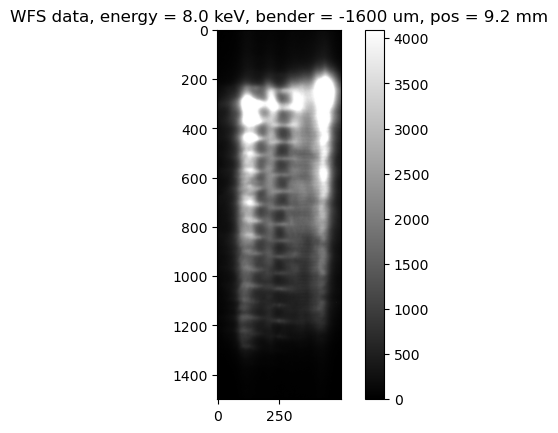

In [7]:
import matplotlib.pyplot as plt
plt.imshow(img_np[1500:3000,100:600], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))       
plt.colorbar()
plt.show()


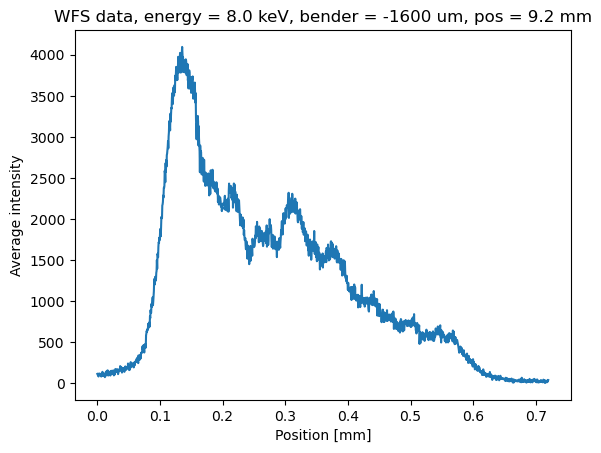

In [4]:
line_avg = img_np[1500:3000,450:451].mean(axis=1)
px_m = 2.40/5/1e6

x_m = np.arange(line_avg.shape[0])*px_m
plt.plot(x_m*1e3, line_avg)
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))
plt.xlabel('Position [mm]')
plt.ylabel('Average intensity')
plt.show()


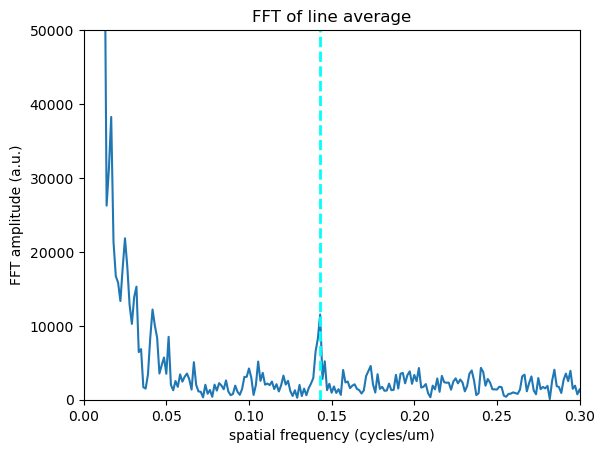

In [5]:
import numpy as np
grating_freq_cpm = 1/(7e-6)  # cycles per meter for 7 um pitch

f_cpm = np.fft.fftshift(np.fft.fftfreq(line_avg.size, d=px_m))
IMG = np.fft.fftshift(np.fft.fft(line_avg))
plt.plot(f_cpm*1e-6, np.abs(IMG))
plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 50000)
plt.show()  

In [6]:
wavelength_m = 1.24e-6 / (mono_energy_eV[0])  # Convert eV to wavelength in meters
grating_pitch_m = 7e-6  # 7 microns in meters   

line = line_avg
line_FFT = np.fft.fftshift(np.fft.fft(line, axis=0), axes=0)
freq_y_cpm = np.fft.fftshift(np.fft.fftfreq(line.shape[0], px_m))

#from scipy.signal import find_peaks

# Transform intensity pattern to frequency domain
I_fft = line_FFT

# Create frequency array
freq = freq_y_cpm
M = len(freq)
df = freq[1]-freq[0]  # Frequency resolution [1/m]

mask = (freq > 0.12e6) & (freq < 0.17e6)

# Find peaks in FFT spectrum (use magnitude)
I_fft_magnitude = np.abs(I_fft)
# peaks, properties = find_peaks(I_fft_magnitude*mask, height=np.max(I_fft_magnitude*mask)*0.1)

# Identify carrier frequency (should be at ±1/pitch)
carrier_freq_ideal = grating_freq_cpm
#carrier_idx = peaks[np.argmin(np.abs(freq[peaks] - carrier_freq_ideal))]
carrier_idx = np.argmax(I_fft_magnitude*mask)
carrier_freq_measured = freq[carrier_idx]


# Create Gaussian filter centered on +1 order
filter_width = 10.0  # pixels (standard deviation)
x_indices = np.arange(M)
gaussian_filter = np.exp(-0.5 * ((x_indices - carrier_idx) / filter_width)**2)

# Apply filter to FFT
I_fft_filtered = I_fft * gaussian_filter



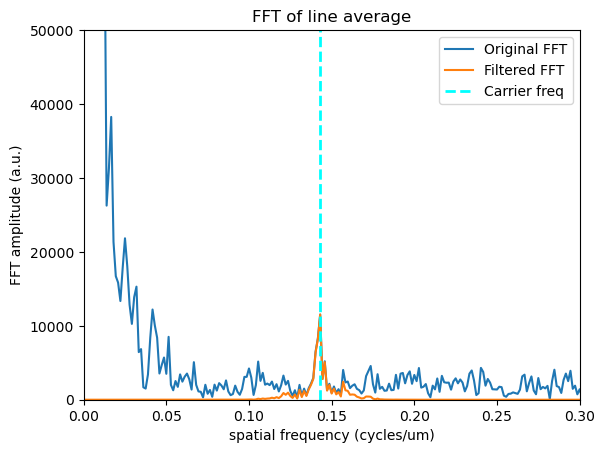

In [7]:
plt.plot(freq*1e-6, np.abs(I_fft), label='Original FFT')
plt.plot(freq*1e-6, np.abs(I_fft_filtered), label='Filtered FFT')
plt.axvline(carrier_freq_measured * 1e-6, color='cyan', linestyle='--', linewidth=2, label='Carrier freq')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 50000)
plt.legend()

In [8]:

# Normalize for visualization (so all curves are visible on same plot)
I_fft_magnitude_norm = I_fft_magnitude / np.max(I_fft_magnitude)
I_fft_filtered_norm = np.abs(I_fft_filtered) / np.max(np.abs(I_fft_magnitude))

# Inverse FFT to get complex field
complex_field = np.fft.ifft(np.fft.ifftshift(I_fft_filtered))

# Extract amplitude and wrapped phase
amplitude = np.abs(complex_field)
phase_wrapped = np.angle(complex_field)

# Standard unwrap (left-to-right) and center at x=0
phase_unwrapped = np.unwrap(phase_wrapped)
phase_centered = phase_unwrapped - phase_unwrapped[M//2]

dy_m = x_m[1] - x_m[0]  # Spatial sampling interval [m]

# Simple cumulative integration with scaling
wavefront_m = np.cumsum(phase_centered) * dy_m / grating_pitch_m * wavelength_m / 2

# Re-center at x=0 to remove piston term
wavefront_reconstructed = wavefront_m - wavefront_m[M//2]
wavefront_wave = wavefront_reconstructed # Convert to meters




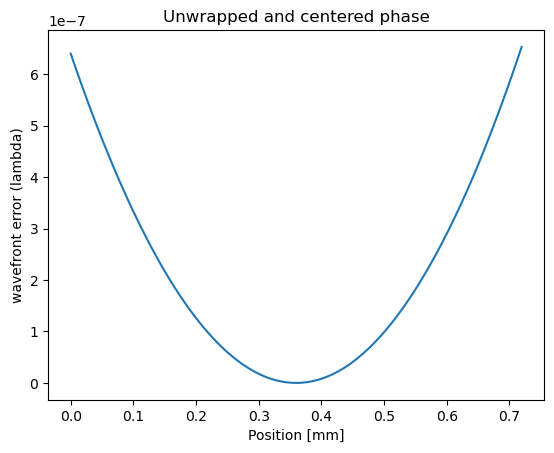

In [11]:
# wavefront error in lambda
plt.plot(x_m*1e3, wavefront_wave)
plt.title('Unwrapped and centered phase')
plt.xlabel('Position [mm]')
plt.ylabel('wavefront error (lambda)')
plt.show()

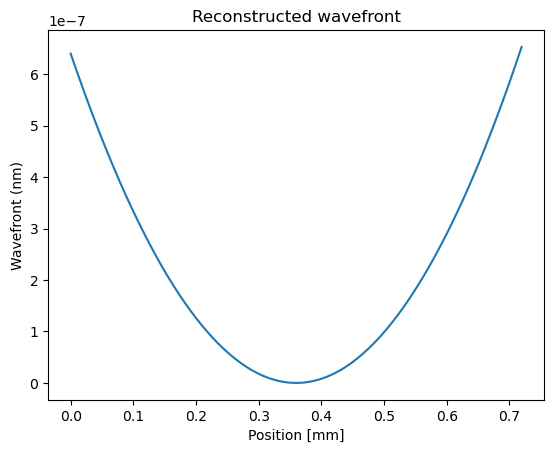

In [10]:
plt.plot(x_m*1e3, wavefront_reconstructed)
plt.title('Reconstructed wavefront')
plt.xlabel('Position [mm]')
plt.ylabel('Wavefront (nm)')
plt.show()


## Bender scan at position 13
We think we're on row 5 with 7 um shearing grating

In [ ]:
# from bluesky.plans import scan
# # RE(scan([basler_camera], Obender, -1361, -1361, 1))
# RE(scan([basler_camera], Obender, -2000, 0, 16))

('bcd61661-8218-4b10-ac2b-e66439c072bc',)

In [12]:
#uid = _
uid = 'bcd61661-8218-4b10-ac2b-e66439c072bc'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
bends_um = db['primary']['bender_um'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

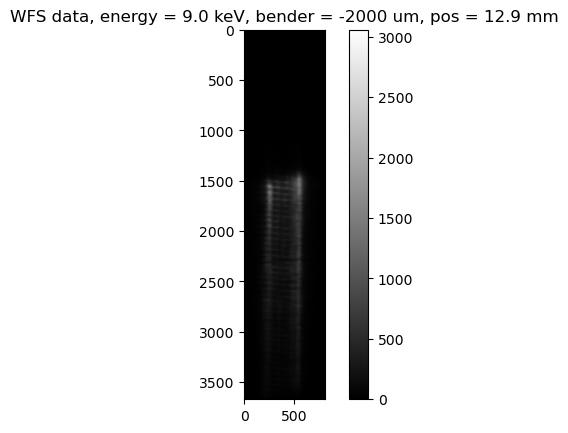

In [37]:
#%matplotlib qt5
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(images[0], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (E_eV[0]*1e-3, bender_um[0], wfs_chip_pos_mm[0]))
plt.colorbar()
plt.show()


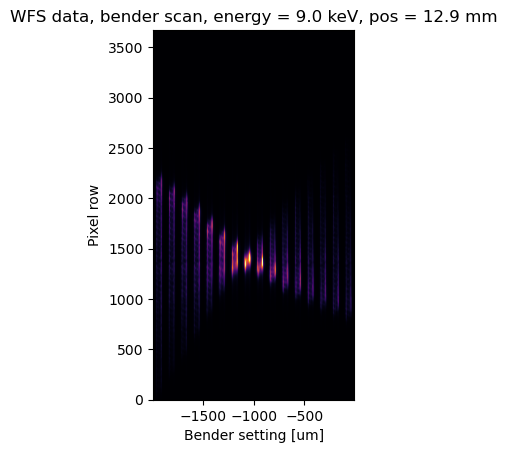

In [18]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,:])

plt.imshow(stacked_image, cmap='inferno',extent=(bends_um[0], bends_um[-1], 0, stacked_image.shape[0]), origin='upper')
plt.title('Horizontally Stacked Images')
plt.title('WFS data, bender scan, energy = %1.1f keV, pos = %.1f mm' % (E_eV[0]*1e-3, wfs_chip_pos_mm[0]))
plt.xlabel('Bender setting [um]')
plt.ylabel('Pixel row')
plt.show()

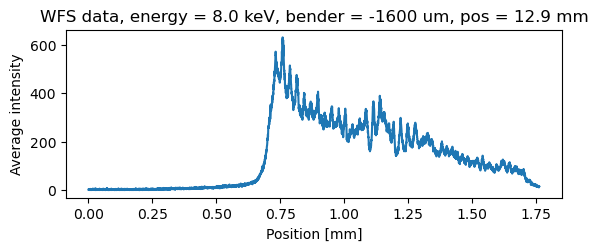

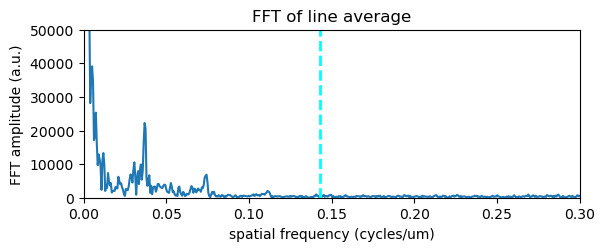

In [48]:
import numpy as np

idx = 0
grating_freq_cpm = 1/(7e-6)  # cycles per meter for 7 um pitch

img_np = np.array(images[idx])
line_avg = img_np[:,450:451].mean(axis=1)

px_m = 2.40e-6/5
x_m = np.arange(line_avg.shape[0])*px_m
f_cpm = np.fft.fftshift(np.fft.fftfreq(line_avg.size, d=px_m))
IMG = np.fft.fftshift(np.fft.fft(line_avg))

plt.subplot(2,1,1)
plt.plot(x_m*1e3, line_avg)
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[0]*1e-3, bends[0], wfs_chip_pos_mm[0]))
plt.xlabel('Position [mm]')
plt.ylabel('Average intensity')
plt.show()

plt.subplot(2,1,2)
plt.plot(f_cpm*1e-6, np.abs(IMG))
plt.axvline(grating_freq_cpm * 1e-6, color='cyan', linestyle='--', linewidth=2, label='7um pitch')
plt.xlabel('spatial frequency (cycles/um)')
plt.ylabel('FFT amplitude (a.u.)')
plt.title('FFT of line average')
plt.xlim(0, 0.30)  # focus on positive frequencies
plt.ylim(0, 50000)
plt.show()  




## Energy scan 

In [93]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 8000, 9000, 11))



Transient Scan ID: 3     Time: 2026-03-20 14:34:23
Persistent Unique Scan ID: 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:34:41.5 |              8000.184 |                20.7550 |
|         2 | 14:34:45.3 |              8099.982 |                20.5750 |
|         3 | 14

('eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a',)

In [121]:
uid = 'eff5f4d9-f29c-424c-a8cc-e77ab64c6b4a'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

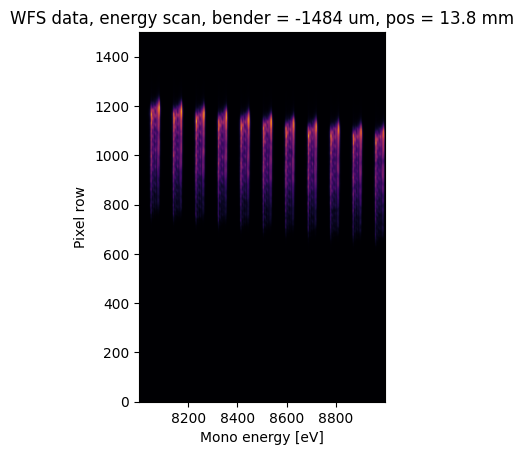

In [ ]:
import numpy as np

# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [107]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 7000, 10000, 21))



Transient Scan ID: 4     Time: 2026-03-20 14:41:11
Persistent Unique Scan ID: '9f354b67-6a48-43f7-b3f8-72985e90ea21'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:41:50.9 |              6999.820 |                22.8540 |
|         2 | 14:41:56.4 |              7149.963 |                22.5000 |
|         3 | 14

('9f354b67-6a48-43f7-b3f8-72985e90ea21',)

In [123]:
uid = '9f354b67-6a48-43f7-b3f8-72985e90ea21'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

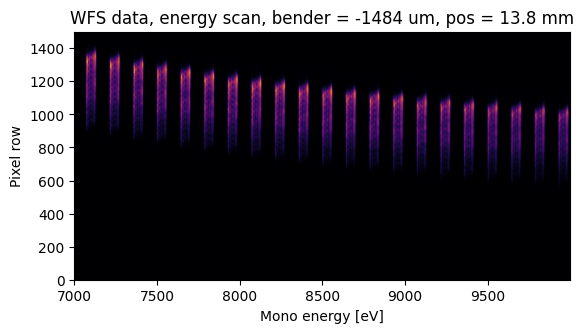

In [124]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [125]:
from bluesky.plans import scan
Obender.move(-1484)
RE(scan([basler_camera], mono_energy, 5000, 11000, 61))



Transient Scan ID: 5     Time: 2026-03-20 14:55:35
Persistent Unique Scan ID: 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 9999.769788152656              |
|         mono_energy_mono_angle | 17.85                          |
|                      bender_um | -1483.9931100000001            |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |
+-----------+------------+-----------------------+------------------------+
|         1 | 14:57:59.7 |              4999.987 |                29.7410 |
|         2 | 14:58:15.7 |              5100.013 |                29.2580 |
|         3 | 14

('acfd18bf-3ffe-4fa0-a381-2be8e82ca207',)

In [126]:
uid = 'acfd18bf-3ffe-4fa0-a381-2be8e82ca207'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
# metadata
E_eV = db['baseline']['mono_energy_energy_eV']
bender_um = db['baseline']['bender_um']
wfs_chip_pos_mm = db['baseline']['bcs_linear_motor']

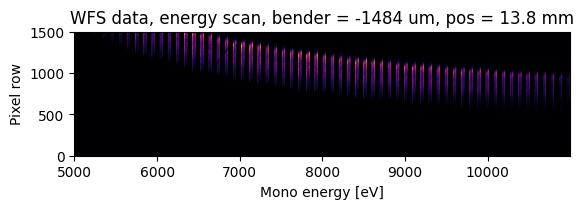

In [127]:
# Stack the images horizontally
stacked_image = np.hstack(images[:,:,1000:1500])
plt.imshow(stacked_image, cmap='inferno',extent=(mono_energy_eV[0], mono_energy_eV[-1], 0, stacked_image.shape[0]), origin='upper')
plt.xlabel('Mono energy [eV]')
plt.ylabel('Pixel row')
plt.title('WFS data, energy scan, bender = %.0f um, pos = %.1f mm' % (bender_um[0], wfs_chip_pos_mm[0]))
plt.show()

In [ ]:
from bluesky.plans import grid_scan
#Obender.move(-1484)
RE(grid_scan([basler_camera], mono_energy, 7000, 10000, 7, Obender, -2000, -1000,6, snake_axes=False))  



Transient Scan ID: 7     Time: 2026-03-20 16:45:47
Persistent Unique Scan ID: '2cb2ab5e-8acc-4a66-abec-63ebab791958'
New stream: 'baseline'
Start-of-run baseline readings:
+--------------------------------+--------------------------------+
|          mono_energy_energy_eV | 8999.986357882728              |
|         mono_energy_mono_angle | 19.137                         |
|                      bender_um | -1500.01713                    |
|               bcs_linear_motor | 13.800138                      |
+--------------------------------+--------------------------------+
New stream: 'primary'
+-----------+------------+-----------------------+------------------------+------------+
|   seq_num |       time | mono_energy_energy_eV | mono_energy_mono_angle |  bender_um |
+-----------+------------+-----------------------+------------------------+------------+
|         1 | 16:46:27.2 |              6999.820 |                22.8540 | -1999.98786 |
|         2 | 16:46:33.3 |             

('2cb2ab5e-8acc-4a66-abec-63ebab791958',)

CA.Client.Exception...............................................
    Context: "192.168.10.124:41915"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 09:30:37.128617139
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:35637"
    Source File: modules/ca/src/client/cac.cpp line 1237
    Current Time: Tue Mar 24 2026 14:39:55.919552227
..................................................................


In [50]:
uid = '2cb2ab5e-8acc-4a66-abec-63ebab791958'
db = tiled_client[uid]
images = db['primary']['basler_camera_image'].read()
mono_energy_eV = db['primary']['mono_energy_energy_eV'].read()
bender_um = db['primary']['bender_um'].read()

wfs_chip_pos_mm = db['baseline']['bcs_linear_motor'].read()

In [53]:
idx = 15
print('Energy = %1.1f keV, bender = %.0f um' % (mono_energy_eV[idx]*1e-3, bender_um[idx]))

Energy = 8.0 keV, bender = -1400 um


IndexError: index 15 is out of bounds for axis 0 with size 2

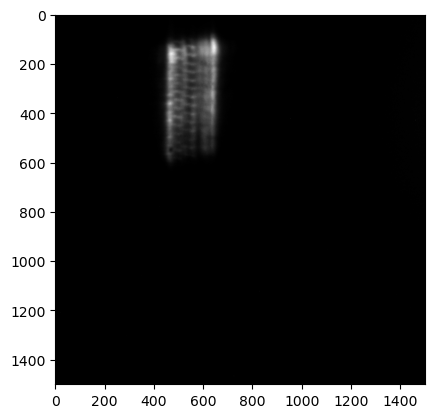

In [54]:
plt.imshow(images[idx], cmap='gray')
plt.title('WFS data, energy = %1.1f keV, bender = %.0f um, pos = %.1f mm' % (mono_energy_eV[idx]*1e-3, bender_um[idx], wfs_chip_pos_mm[idx]))
plt.colorbar()
plt.show()  